In [3]:
import itertools

In [4]:
#!pip install physiomodeler

In [5]:
# ## Deel 5 - Functionele verdeling

# %%
from physiomodeler import Model
import scipy as sp
import numpy as np
elastantie_factor = 0.8
volume_alv_factor = 0.3
# %%
parameters_luchtstromingen = {
    "weerstand_luchtwegopening_luchtwegen": 3.0,
    "weerstand_luchtwegen_alveoli": 2.0,
}
parameters_dynamische_elastantie = {
    "g_thoraxwand": (5, 4.6, -240, -2.3, 0),
    "g_luchtwegen": [11, 0.2, 1e-3, 8, -0.06],
    "g_alveoli": [2.75, 0.8, 1e-3, 2, -0.24],
}


# %%
def input_druk_als_blokgolf(time, inputs):
    periode = 60 / inputs["ademhalingsfrequentie"]
    blokgolf = sp.signal.square(
        time * 2 * np.pi / periode, duty=inputs["druk_duty"]
    )
    luchtwegdruk = (
        (blokgolf + 1)
        / 2
        * inputs["amplitude_luchtwegdruk"]
    )
    luchtwegdruk += inputs["PEEP"]
    return luchtwegdruk


# %%
inputs = {
    "druk_luchtwegopening": input_druk_als_blokgolf,
    "amplitude_luchtwegdruk": 5,
    "ademhalingsfrequentie": 20,
    "druk_duty": 0.5,
    "PEEP": 5,
}


# %%
def elastische_druk(volume, g):
    return (
        g[0] * (volume  - g[1])
        + g[2] * np.exp(g[3] * volume)
        + g[4] / volume
    )


# %%
def drukken_dynamische_elastantie(inputs, parameters):
    V_luchtwegen = inputs["volume_luchtwegen"]
    V_alveoli = inputs["volume_alveoli"]
    V_longen = V_luchtwegen + V_alveoli
    functioneel_volume_alveoli = V_alveoli / elastantie_factor

    P_E_luchtwegen = elastische_druk(
        V_luchtwegen, parameters["g_luchtwegen"]
    )
    P_E_alveoli = elastische_druk(
        functioneel_volume_alveoli, parameters["g_alveoli"]
    )
    P_E_thoraxwand = elastische_druk(
        V_longen, parameters["g_thoraxwand"]
    )

    return {
        "druk_pleura": P_E_thoraxwand,
        "transpulmonale_druk": P_E_alveoli,
        "druk_alveoli": P_E_alveoli + P_E_thoraxwand,
        "elastische_druk_luchtwegen": P_E_luchtwegen,
        "druk_luchtwegen": P_E_luchtwegen + P_E_thoraxwand,
        "volume_longen": V_longen,
    }


dynamische_elastantie_drukken_model = Model(
    dynamics=drukken_dynamische_elastantie,
    parameters=parameters_dynamische_elastantie,
)


# %%
def dynamics(inputs, parameters):
    """Dynamica van een simpel ballon-model van de longen."""
    R_LWO_LW = parameters[
        "weerstand_luchtwegopening_luchtwegen"
    ]
    R_LW_alv = parameters["weerstand_luchtwegen_alveoli"]
    P_LWO = inputs["druk_luchtwegopening"]
    P_LW = inputs["druk_luchtwegen"]
    P_alv = inputs["druk_alveoli"]

    Q_LWO_LW = (P_LWO - P_LW) / R_LWO_LW
    Q_LW_alv = (P_LW - P_alv) / R_LW_alv

    dV_LW = Q_LWO_LW - Q_LW_alv

    totale_flux = (
        inputs["flux_O2_alveoli_PC"]
        + inputs["flux_CO2_alveoli_PC"]
    )
    dV_alv = Q_LW_alv - totale_flux

    return {
        "dvolume_luchtwegen": dV_LW,
        "dvolume_alveoli": dV_alv,
        "debiet_luchtwegopening_luchtwegen": Q_LWO_LW,
        "debiet_luchtwegen_alveoli": Q_LW_alv,
    }


# %%
luchtstromingen_model = Model(
    dynamics=[
        dynamische_elastantie_drukken_model,
        dynamics,
    ],
    state_components=[
        "volume_luchtwegen",
        "volume_alveoli",
    ],
    inputs=inputs,
    parameters=parameters_luchtstromingen,
)

In [6]:
# %%
from physiomodeler import Model

# %%
inputs = {
    "fractie_O2_luchtwegopening": 0.1965,
    "fractie_CO2_luchtwegopening": 0.0003,
}


# %%
def fractie_verandering(
    fractie_a, fractie_b, debiet_a_b, volume_b
):
    if debiet_a_b <= 0:
        return 0

    return (fractie_a - fractie_b) * (debiet_a_b / volume_b)


# %%
def dynamics(state, inputs, parameters):
    gas = parameters["gas"]
    functioneel_volume_alv = inputs["volume_alveoli"] *volume_alv_factor
    dfractie_LWO_LW = fractie_verandering(
        inputs[f"fractie_{gas}_luchtwegopening"],
        state[f"fractie_{gas}_luchtwegen"],
        inputs["debiet_luchtwegopening_luchtwegen"],
        inputs["volume_luchtwegen"],
    )
    dfractie_alv_LW = fractie_verandering(
        state[f"fractie_{gas}_alveoli"],
        state[f"fractie_{gas}_luchtwegen"],
        -inputs["debiet_luchtwegen_alveoli"],
        inputs["volume_luchtwegen"],
    )
    dfractie_LW_alv = fractie_verandering(
        state[f"fractie_{gas}_luchtwegen"],
        state[f"fractie_{gas}_alveoli"],
        inputs["debiet_luchtwegen_alveoli"],
        functioneel_volume_alv,
    )
    dfractie_LW = dfractie_LWO_LW + dfractie_alv_LW
    dfractie_alv = (
        dfractie_LW_alv
        - inputs[f"flux_{gas}_alveoli_PC"]
        / functioneel_volume_alv
    )

    return {
        f"dfractie_{gas}_luchtwegen": dfractie_LW,
        f"dfractie_{gas}_alveoli": dfractie_alv,
    }


# %%
gasstroming_O2_model = Model(
    dynamics=dynamics,
    state_components=[
        "fractie_O2_luchtwegen",
        "fractie_O2_alveoli",
    ],
    inputs=inputs,
    parameters={"gas": "O2"},
)

# %%
gasstroming_CO2_model = Model(
    dynamics=dynamics,
    state_components=[
        "fractie_CO2_luchtwegen",
        "fractie_CO2_alveoli",
    ],
    inputs=inputs,
    parameters={"gas": "CO2"},
)

# %%
gasstromingen_model = Model(
    dynamics=[gasstroming_O2_model, gasstroming_CO2_model],
)

In [7]:
# %%
from physiomodeler import Model

# %%
parameters = {
    "volume_PC": 0.1,
    "volume_SA": 1.1,
    "volume_SC": 0.3,
    "volume_SV": 3.5,
}

# %%
inputs = {
    "cardiac_output": 5 / 60,
    "flux_O2_SC_weefsels": 0.25 / 60,
    "flux_CO2_SC_weefsels": -0.2 / 60,
}


# %%
def dynamics(state, inputs, parameters):
    gas = parameters["gas"]
    compartiment_a = parameters["voorgaand_compartiment"]
    compartiment_b = parameters["compartiment"]

    inhoud_a = inputs[f"inhoud_{gas}_{compartiment_a}"]
    inhoud_b = state[f"inhoud_{gas}_{compartiment_b}"]
    volume_b = parameters[f"volume_{compartiment_b}"]
    cardiac_output = inputs["cardiac_output"]

    dinhoud_a_b = (
        (inhoud_a - inhoud_b) * cardiac_output / volume_b
    )
    if compartiment_b == "PC":
        dinhoud_flux = (
            inputs[f"flux_{gas}_alveoli_PC"] / volume_b
        )
    elif compartiment_b == "SC":
        dinhoud_flux = (
            -inputs[f"flux_{gas}_SC_weefsels"] / volume_b
        )
    else:
        dinhoud_flux = 0

    return {
        f"dinhoud_{gas}_{compartiment_b}": dinhoud_a_b
        + dinhoud_flux
    }


# %%
def dynamics(state, inputs, parameters):
    gas = parameters["gas"]
    compartiment_a = parameters["voorgaand_compartiment"]
    compartiment_b = parameters["compartiment"]

    inhoud_a = inputs[f"inhoud_{gas}_{compartiment_a}"]
    inhoud_b = state[f"inhoud_{gas}_{compartiment_b}"]
    volume_b = parameters[f"volume_{compartiment_b}"]
    cardiac_output = inputs["cardiac_output"]

    dinhoud_a_b = (
        (inhoud_a - inhoud_b) * cardiac_output / volume_b
    )
    if compartiment_b == "PC":
        dinhoud_flux = (
            inputs[f"flux_{gas}_alveoli_PC"] / volume_b
        )
    elif compartiment_b == "SC":
        dinhoud_flux = (
            -inputs[f"flux_{gas}_SC_weefsels"] / volume_b
        )
    else:
        dinhoud_flux = 0

    return {
        f"dinhoud_{gas}_{compartiment_b}": dinhoud_a_b
        + dinhoud_flux,
        f"delivery_{gas}_{compartiment_a}_{compartiment_b}": inhoud_a
        * cardiac_output,
    }


# %%
modellen = []
for gas in ("O2", "CO2"):
    for compartiment_a, compartiment_b in (
        ("SV", "PC"),
        ("PC", "SA"),
        ("SA", "SC"),
        ("SC", "SV"),
    ):
        model = Model(
            dynamics=dynamics,
            state_components=[
                f"inhoud_{gas}_{compartiment_b}"
            ],
            parameters={
                "gas": gas,
                "compartiment": compartiment_b,
                "voorgaand_compartiment": compartiment_a,
            },
        )
        modellen.append(model)


# %%
def event_concentratie_O2_negatief(state):
    return state["inhoud_O2_SC"]


event_concentratie_O2_negatief.terminal = True

# %%
perfusie_model = Model(
    dynamics=modellen,
    inputs=inputs,
    parameters=parameters,
    events=[event_concentratie_O2_negatief],
)

In [8]:
# %%
import numpy as np
from physiomodeler import Model

# %%dddd
inputs = {
    "druk_atmosfeer": 1033,  # cmH2O
}

# %%
parameters = {
    "kPa_per_cmH2O": 0.0981,  # kPa/cmH2O,
    "bindingscapaciteit_Hb_per_gram": 1.35e-3,  # L(O2)/g(Hb)
    "concentratie_Hb": 150,  # g(Hb)/L(bloed)
    "diffusiecapaciteit_O2_alveoli_PC": 0.0042,  # L/(s*kPa)
    "diffusiecapaciteit_CO2_alveoli_PC": 0.025,
}


# %%
def partiele_drukken_lucht(inputs):
    P_alv_abs_cmH2O = (
        inputs["druk_alveoli"] + inputs["druk_atmosfeer"]
    )
    P_alv_abs_kPa = (
        P_alv_abs_cmH2O * parameters["kPa_per_cmH2O"]
    )
    return {
        "partiele_druk_O2_alveoli": P_alv_abs_kPa
        * inputs["fractie_O2_alveoli"],
        "partiele_druk_CO2_alveoli": P_alv_abs_kPa
        * inputs["fractie_CO2_alveoli"],
    }


# %%
def partiele_drukken_lucht(inputs):
    resultaten = {}
    for compartiment in ["alveoli", "luchtwegen"]:
        P_abs_cmH2O = (
            inputs[f"druk_{compartiment}"]
            + inputs["druk_atmosfeer"]
        )
        P_abs_kPa = (
            P_abs_cmH2O * parameters["kPa_per_cmH2O"]
        )
        resultaten.update(
            {
                f"partiele_druk_O2_{compartiment}": P_abs_kPa
                * inputs[f"fractie_O2_{compartiment}"],
                f"partiele_druk_CO2_{compartiment}": P_abs_kPa
                * inputs[f"fractie_CO2_{compartiment}"],
            }
        )
    return resultaten


# %%
def partiele_druk_O2_bij_saturatie(saturatie):
    h2 = 2.81
    y_N = 55.5 * saturatie / (1 - saturatie)

    a = (y_N + np.sqrt(y_N**2 + h2)) / 2
    b = (y_N - np.sqrt(y_N**2 + h2)) / 2

    # Een negatief getal tot een breuk verheffen geeft een complex getal. In
    # plaats daarvan converteren we naar een positief getal en zetten we het
    # originele teken er weer bij terug na machtsverheffing.
    # np.abs(a) converteert a naar een positief getal.
    # np.sign(a) converteert na machtsverheffing terug naar het originele teken.
    return np.sign(a) * np.abs(a) ** (1 / 3) + np.sign(
        b
    ) * np.abs(b) ** (1 / 3)


# %%
def partiele_druk_CO2_bij_inhoud(inhoud):
    return 0.837 * np.exp(4.16 * inhoud) - 0.895


# %%
def partiele_drukken_bloed(inputs, parameters):
    concentratie_Hb = parameters["concentratie_Hb"]
    bindingscapaciteit_O2_Hb = parameters[
        "bindingscapaciteit_Hb_per_gram"
    ]
    totale_bindingscapaciteit_O2 = (
        concentratie_Hb * bindingscapaciteit_O2_Hb
    )

    resultaten = {}
    for compartiment in ["PC", "SA", "SC", "SV"]:
        resultaten[f"saturatie_O2_{compartiment}"] = (
            inputs[f"inhoud_O2_{compartiment}"]
            / totale_bindingscapaciteit_O2
        )

        resultaten[f"partiele_druk_O2_{compartiment}"] = (
            partiele_druk_O2_bij_saturatie(
                resultaten[f"saturatie_O2_{compartiment}"]
            )
        )
        resultaten[f"partiele_druk_CO2_{compartiment}"] = (
            partiele_druk_CO2_bij_inhoud(
                inputs[f"inhoud_CO2_{compartiment}"]
            )
        )

    return resultaten


# %%
def flux_alveoli_PC(parameters, inputs):
    gas = parameters["gas"]

    diffusiecapaciteit = parameters[
        f"diffusiecapaciteit_{gas}_alveoli_PC"
    ]

    partiele_druk_alveoli = inputs[
        f"partiele_druk_{gas}_alveoli"
    ]
    partiele_druk_PC = inputs[f"partiele_druk_{gas}_PC"]

    return {
        f"flux_{gas}_alveoli_PC": diffusiecapaciteit
        * (partiele_druk_alveoli - partiele_druk_PC)
    }


# %%
flux_O2_alveoli_PC_model = Model(
    dynamics=flux_alveoli_PC,
    parameters={"gas": "O2"},
)

flux_CO2_alveoli_PC_model = Model(
    dynamics=flux_alveoli_PC,
    parameters={"gas": "CO2"},
)

# %%
flux_alveoli_PC_model = Model(
    dynamics=[
        partiele_drukken_lucht,
        partiele_drukken_bloed,
        flux_O2_alveoli_PC_model,
        flux_CO2_alveoli_PC_model,
    ],
    parameters=parameters,
    inputs=inputs,
)

In [9]:
systeem_model = Model(
    dynamics=[
        dynamische_elastantie_drukken_model,
        flux_alveoli_PC_model,
        luchtstromingen_model,
        gasstromingen_model,
        perfusie_model,
    ],
)

In [10]:
result = systeem_model.run_simulation(
    time=60,
    initial_state={
        "volume_luchtwegen": 0.7,
        "volume_alveoli": 2.8,
        "inhoud_O2_PC": 0.15,  # ±saturatie van 75%
        "inhoud_O2_SA": 0.15,
        "inhoud_O2_SC": 0.15,
        "inhoud_O2_SV": 0.15,
    },
)

array([<Axes: xlabel='time'>, <Axes: xlabel='time'>,
       <Axes: xlabel='time'>, <Axes: xlabel='time'>], dtype=object)

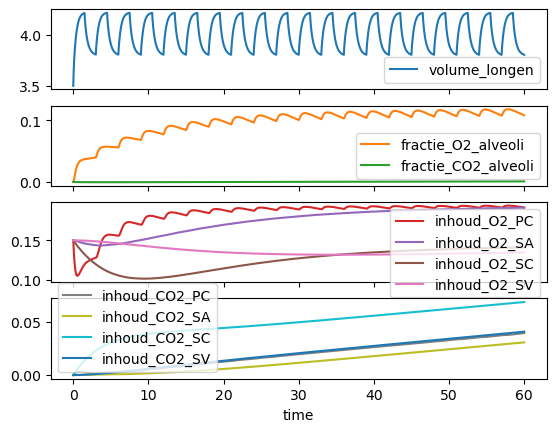

In [11]:
columns = [
    ["volume_longen"],
    ["fractie_O2_alveoli", "fractie_CO2_alveoli"],
    [
        "inhoud_O2_PC",
        "inhoud_O2_SA",
        "inhoud_O2_SC",
        "inhoud_O2_SV",
    ],
    [
        "inhoud_CO2_PC",
        "inhoud_CO2_SA",
        "inhoud_CO2_SC",
        "inhoud_CO2_SV",
    ],
]
result[[*itertools.chain(*columns)]].plot(subplots=columns)